In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
column_names = [
    "checking_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "telephone",
    "foreign_worker",
    "target"
]

In [4]:
data_path = Path("../data/raw/german.data")

df = pd.read_csv(
    data_path,
    sep=r"\s+",
    header=None,
    names=column_names
)

df.head()

,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
print("Shape:", df.shape)
df.info()

Shape: (1000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_status          1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_status           1000 non-null   str  
 6   employment_since         1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15

In [6]:
df["target"].value_counts()

target
1    700
2    300
Name: count, dtype: int64

In [7]:
df.isnull().sum()

checking_status            0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
telephone                  0
foreign_worker             0
target                     0
dtype: int64

In [8]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


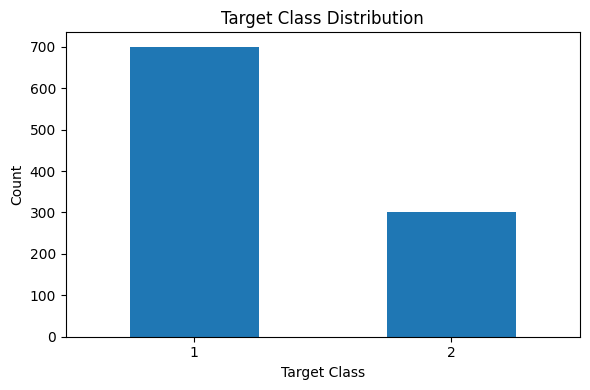

In [9]:
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6,4))
target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
df["target_binary"] = df["target"].map({
    1: 0,  # good credit risk
    2: 1   # bad credit risk
})

df[["target", "target_binary"]].head()

,target,target_binary
0,1,0
1,2,1
2,1,0
3,1,0
4,2,1


In [11]:
numeric_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_since",
    "age",
    "existing_credits",
    "num_dependents"
]

categorical_features = [
    "checking_status",
    "credit_history",
    "purpose",
    "savings_status",
    "employment_since",
    "personal_status_sex",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 7
Categorical features: 13


In [12]:
processed_path = Path("../data/processed/german_credit_clean.csv")

df.to_csv(processed_path, index=False)

print("Saved cleaned dataset to:", processed_path)

Saved cleaned dataset to: ..\data\processed\german_credit_clean.csv
